# Rapport d'analyse et guide operationnel : Gestion des aleas et adaptation dynamique du bloc operatoire

Ce notebook presente le fonctionnement et les performances du **systeme de gestion des aleas** et d'**adaptation dynamique** developpe pour le bloc operatoire hospitalier.

Le pilotage quotidien d'un bloc chirurgical est confronte a une forte variabilite :
- **Urgences imprevues** a integrer rapidement sans desorganiser l'ensemble des interventions ;
- **Annulations de derniere minute** liberant du temps de salle et des lits d'hospitalisation ;
- **Indisponibilite inopinee de lits** (tensions d'effectifs, fermeture temporaire de chambres) reduisant la capacite d'admission ;
- **Retards de vacations** (depassements operatoires, temps de preparation prolonge).

Pour repondre a ces defis, le systeme propose deux approches complementaires :
1. **Une approche proactive : la generation de plannings alternatifs** (profil nominal, robuste avec marge tampon, securite lits, et proposition de double creneau **Date A / Date B** par patient pour eclairer la decision du praticien).
2. **Une approche reactive : l'adaptation dynamique sous contrainte de stabilite** (gel des interventions passees, insertion prioritaire des urgences, respect des fenetres cliniques et minimisation des perturbations de planning).

## 1. Imports et initialisation de l'environnement

On charge les bibliotheques usuelles (`pandas`, `numpy`, `matplotlib`) et les modules du package `optimiseur`.

In [1]:
import os
import sys
from pathlib import Path

# Fix pour OpenBLAS sous Windows / Python 3.14
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rendre le package optimiseur importable depuis la racine du depot
NOTEBOOK_DIR = Path.cwd()
REPO = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from optimiseur import optimizer as op
from optimiseur import aleas as al
from optimiseur import plotting as pl

print(f"Environnement initialise. Racine du depot : {REPO}")

Environnement initialise. Racine du depot : C:\Users\cornu\Documents\IAS méta heuristix\IA-et-Sante-groupe-2


## 2. Generation des donnees de base du bloc operatoire

On genere un jeu de donnees representatif d'une semaine de bloc operatoire :
- **30 patients** electifs repartis sur 4 specialites chirurgicales (`Orthopedie`, `Digestif`, `Cardio`, `ORL`) ;
- **5 jours** d'activite (jours 0 a 4) ;
- **Vacations** de 240 minutes par jour et par specialite ;
- **Capacite en lits** : 35 lits d'hospitalisation conventionnelle.

In [2]:
patients_df, vacations_df = op.generate_test_data(
    n_patients=30,
    n_days=5,
    vacations_par_jour_par_specialite=1,
    seed=42,
)

print(f"Patients generes ({len(patients_df)}) :")
display(patients_df.head(6))

print(f"\nVacations disponibles ({len(vacations_df)}) :")
display(vacations_df.head(6))

Patients generes (30) :


,patient_id,specialite,duree_operatoire,duree_sejour
0,0,Orthopedie,122,3
1,1,Digestif,81,4
2,2,Orthopedie,113,1
3,3,Orthopedie,93,4
4,4,Cardio,121,3
5,5,ORL,91,0



Vacations disponibles (20) :


,vacation_id,jour,specialite,capacite_min
0,0,0,Orthopedie,240
1,1,0,Digestif,240
2,2,0,Cardio,240
3,3,0,ORL,240
4,4,1,Orthopedie,240
5,5,1,Digestif,240


## 3. Optimisation du planning nominal initial

On modelise le probleme sous forme d'une instance `PlanningProblem` et on recherche le meilleur planning a l'aide des metaheuristiques.

In [3]:
problem_nominal = op.PlanningProblem(
    patients_df,
    vacations_df,
    lits_capacity=35,
    w_vacation=5.0,
    w_lits=3.0,
    w_balance=0.05,
)

print(f"Probleme initialise : {problem_nominal.n_patients} patients, {problem_nominal.n_vacations} vacations, {problem_nominal.n_days} jours.")

# Optimisation avec les 5 metaheuristiques
resultats_init = op.optimize_planning(patients_df, vacations_df, lits_capacity=35, seed=42)

for nom, r in resultats_init.items():
    print(f"{nom:<16s} fitness = {r.meilleure_fitness:10.3f}   temps = {op.format_duree(r.duree_s):>9s}")

meilleure_methode = max(resultats_init, key=lambda n: resultats_init[n].meilleure_fitness)
solution_nominale = resultats_init[meilleure_methode].meilleure_solution
print(f"\n-> Meilleure methode retenue pour le planning nominal : {meilleure_methode}")

Probleme initialise : 30 patients, 20 vacations, 5 jours.


Recuit simule    fitness =     -1.566   temps = 101.33 ms
Tabou            fitness =     -1.566   temps = 122.74 ms
Genetique        fitness =     -2.016   temps = 279.26 ms
Tabou x Recuit   fitness =     -1.566   temps = 332.11 ms
Fourmis (ACO)    fitness =     -2.060   temps =    1.13 s

-> Meilleure methode retenue pour le planning nominal : Recuit simule


### Visualisation du planning nominal et de l'occupation des lits

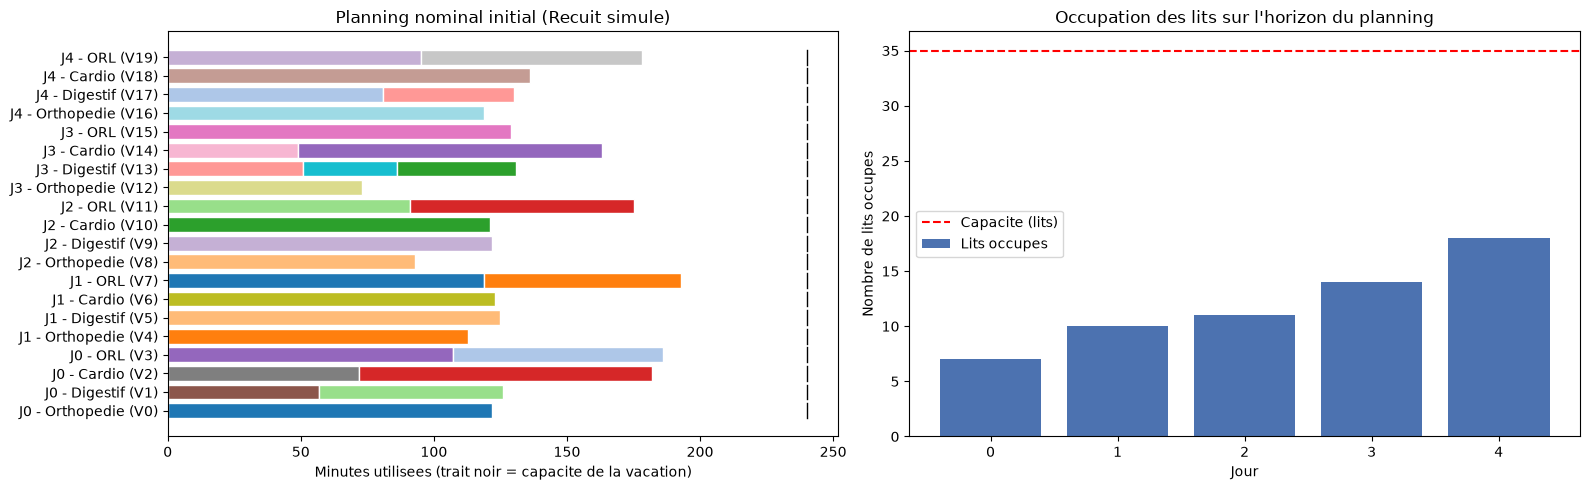

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
pl.plot_planning(problem_nominal, solution_nominale, titre=f"Planning nominal initial ({meilleure_methode})", ax=axes[0])
pl.plot_occupation_lits(problem_nominal, solution_nominale, ax=axes[1])
plt.show()

## 4. Approche 1 : Generation proactive de plannings alternatifs

Pour ne pas subir les imprevus, l'etablissement hospitalier peut generer en amont des **profils de plannings alternatifs** aux caracteristiques complementaires :

1. **Nominal** : optimisation a 100% de la capacite (recherche d'efficience standard) ;
2. **Robuste Bufferise** : reserve de capacite bloc (buffer de 15%) et lits pour absorber les imprevus sans aucun decalage de patient ;
3. **Securite Lits** : forte priorite au lissage de l'occupation pour eliminer les pics d'hospitalisation ;
4. **Alternatif Diversifie (Date B)** : solution de haute qualite explorant d'autres combinaisons afin d'offrir une seconde option credible au patient et au chirurgien.

In [5]:
plannings_alternatifs = al.generer_plannings_alternatifs(
    problem_nominal,
    solution_nominale=solution_nominale,
    marge_buffer_bloc=0.15,
    marge_buffer_lits=0.15,
    seed=42,
)

metrics = []
for nom, alt in plannings_alternatifs.items():
    metrics.append({
        "Profil": nom,
        "Fitness": f"{alt.fitness:.2f}",
        "Depassement bloc (min)": f"{alt.overflow_vacation:.1f}",
        "Depassement lits": f"{alt.overflow_lits:.1f}",
        "Marge moy. bloc": f"{alt.marge_moyenne_bloc_min:.1f} min",
        "Pic maximal lits": f"{alt.pic_lits} lits",
        "Divergence vs Nominal": f"{alt.taux_patients_differents*100:.1f} %",
    })

display(pd.DataFrame(metrics))

,Profil,Fitness,Depassement bloc (min),Depassement lits,Marge moy. bloc,Pic maximal lits,Divergence vs Nominal
0,Nominal,-1.57,0.0,0.0,103.0 min,18 lits,0.0 %
1,Robuste_Buffer,-1.57,0.0,0.0,103.0 min,17 lits,73.3 %
2,Securite_Lits,-1.57,0.0,0.0,103.0 min,18 lits,90.0 %
3,Alternatif_Date_B,-1.57,0.0,0.0,103.0 min,19 lits,100.0 %


### Comparaison graphique des 4 profils alternatifs

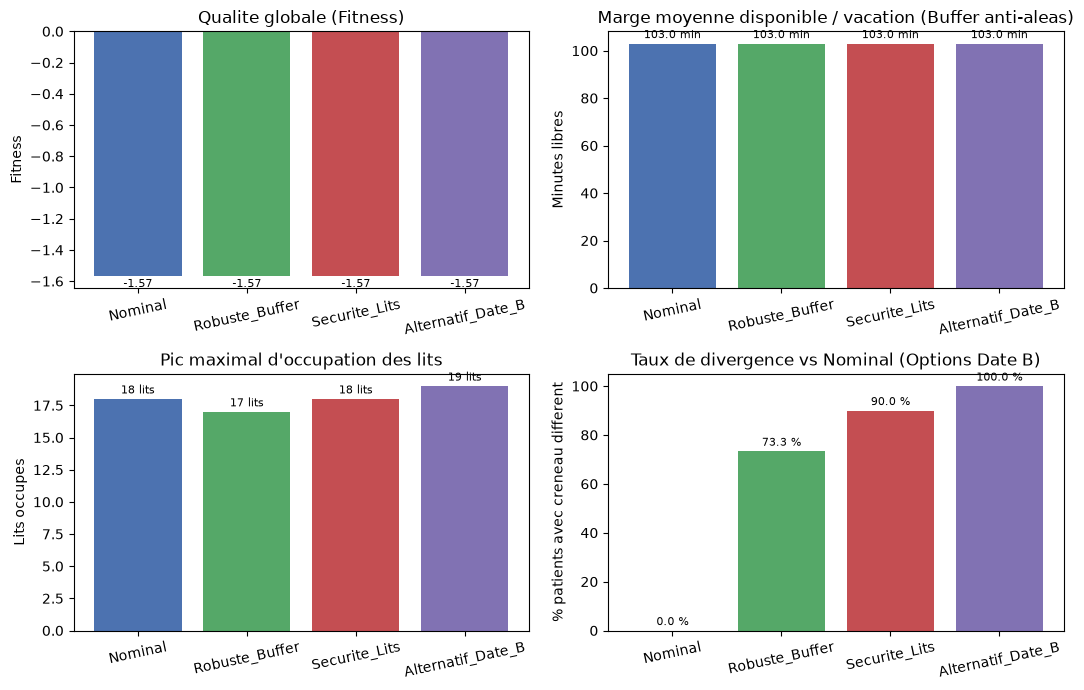

In [6]:
fig_alt = pl.plot_comparaison_alternatives(plannings_alternatifs)
plt.show()

### Aide a la decision medicale : Tableau des options Date A / Date B

Conformement aux directives hospitalieres, le chirurgien ou sa secretaire peut proposer lors de la consultation preparatoire :
- **Option Date A** : date nominale optimale ;
- **Option Date B** : date alternative credible et compatible avec les lits et le bloc.

In [7]:
df_dates_ab = al.extraire_options_date_a_b(
    problem_nominal,
    plannings_alternatifs["Nominal"].solution,
    plannings_alternatifs["Alternatif_Date_B"].solution,
)

nb_distincts = df_dates_ab["jours_distincts"].sum()
print(f"Tableau Date A / Date B pour les 30 patients ({nb_distincts} patients avec jours distincts) :")
display(df_dates_ab.head(10))

Tableau Date A / Date B pour les 30 patients (30 patients avec jours distincts) :


,patient_id,specialite,duree_operatoire,duree_sejour,option_A_jour,option_A_vacation,option_B_jour,option_B_vacation,jours_distincts,meme_creneau,recommandation
0,0,Orthopedie,122,3,0,0,3,12,True,False,Alternative a J3 proposee
1,10,Digestif,57,0,0,1,4,17,True,False,Alternative a J4 proposee
2,25,Digestif,69,1,0,1,4,17,True,False,Alternative a J4 proposee
3,14,Cardio,72,0,0,2,2,10,True,False,Alternative a J2 proposee
4,26,Cardio,110,4,0,2,2,10,True,False,Alternative a J2 proposee
5,8,ORL,107,2,0,3,2,11,True,False,Alternative a J2 proposee
6,21,ORL,79,1,0,3,2,11,True,False,Alternative a J2 proposee
7,2,Orthopedie,113,1,1,4,0,0,True,False,Alternative a J0 proposee
8,23,Digestif,125,0,1,5,3,13,True,False,Alternative a J3 proposee
9,16,Cardio,123,3,1,6,4,18,True,False,Alternative a J4 proposee


## 5. Modelisation et injection des 4 types d'aleas

A l'etape du **Jour 1**, quatre aleas majeurs et simultanes surviennent au bloc operatoire :

1. **Urgences vitales et relatives** :
   - `URG_1` : Patient orthopedique urgent (90 min d'intervention, sejour 2 jours, delai max : 0 jour / jour meme) ;
   - `URG_2` : Patient de chirurgie cardiaque urgent (75 min d'intervention, sejour 3 jours, delai max : 1 jour).
2. **Annulation de patient electif** :
   - Un patient programme au jour 2 annule suite a une contre-indication anesthesique de derniere minute.
3. **Indisponibilite inopinee de lits** :
   - Fermeture d'urgence de 5 lits d'hospitalisation aux jours 1 et 2 en raison d'un manque d'infirmiers.
4. **Retard de bloc operatoire** :
   - Une vacation de cardiologie subit un retard de 45 minutes suite a une complication technique imprevue.

In [8]:
jour_courant = 1

scenario = al.ScenarioAleas(nom="Scenario Crise Reelle au Jour 1")

# 1. Ajout de 2 urgences
scenario.ajouter_urgence(
    patient_id="URG_1",
    specialite="Orthopedie",
    duree_operatoire=90.0,
    duree_sejour=2,
    jour_apparition=jour_courant,
    delai_max_jours=0,  # le jour meme imperativement
    priorite=1,
    motif="Fracture ouverte - Urgence vitale",
)

scenario.ajouter_urgence(
    patient_id="URG_2",
    specialite="Cardio",
    duree_operatoire=75.0,
    duree_sejour=3,
    jour_apparition=jour_courant,
    delai_max_jours=1,  # sous 24h a 48h
    priorite=2,
    motif="Syndrome coronarien aigu",
)

# 2. Ajout d'une annulation parmi les patients programmes a partir de Jour 1
pid_annule = None
for pid, vac_idx in solution_nominale.items():
    if problem_nominal._vac_day[vac_idx] >= jour_courant:
        pid_annule = problem_nominal.patients.loc[pid, "patient_id"]
        break

if pid_annule is not None:
    scenario.ajouter_annulation(
        patient_id=pid_annule,
        jour_notification=jour_courant,
        motif="Contre-indication anesthesique (bilan biologique anormal)",
    )

# 3. Indisponibilite de 5 lits au Jour 1 et Jour 2
scenario.ajouter_indisponibilite_lits(
    jour_debut=jour_courant,
    jour_fin=min(problem_nominal.n_days - 1, jour_courant + 1),
    lits_perdus=5,
    motif="Tension RH soignante / chambres d'isolement requises",
)

# 4. Retard de bloc de 45 minutes sur une vacation du jour courant
vac_jour1 = vacations_df[vacations_df["jour"] == jour_courant].iloc[0]
scenario.ajouter_retard_bloc(
    vacation_id=int(vac_jour1["vacation_id"]),
    retard_min=45.0,
    motif="Prolongation premiere intervention suite a complication",
)

print(scenario.resume())

Scenario : Scenario Crise Reelle au Jour 1 (5 aleas au total)
  - Urgences : 2
  - Annulations : 1
  - Indisponibilites lits : 1
  - Retards bloc : 1


## 6. Approche 2 : Adaptation dynamique reactive (Reactive Replanning)

Le moteur d'adaptation dynamique resout la perturbation selon les regles suivantes :
- **Sanctuarisation du passe** : tous les patients dont l'intervention a eu lieu au Jour 0 sont **geles** ;
- **Integration des flux** : le patient annule est deprogramme, les creneaux et lits sont liberes ; les urgences sont inserees dans leur creneau clinique ;
- **Principe de moindre perturbation** : l'algorithme privilegie la stabilite et ne deplace un patient electif futur que si cela evite un depassement critique de capacite bloc ou lits.

In [9]:
adaptation_result = al.adapter_planning(
    problem=problem_nominal,
    solution_initiale=solution_nominale,
    scenario=scenario,
    jour_courant=jour_courant,
    w_perturbation=3.0,      # cout d'instabilite pour un deplacement meme jour
    w_changement_jour=8.0,   # penalite forte si on change la date du patient
    n_iter=350,
    seed=42,
)

print(adaptation_result.rapport)

             RAPPORT D'ADAPTATION DYNAMIQUE DU BLOC OPERATOIRE
Point d'etape : Jour courant 1 | Temps d'optimisation reactive : 331.0 ms
Qualite du planning : Fitness initiale =    -1.57 -> Fitness adaptee =    -1.94
------------------------------------------------------------------------------
1. SYNTHESE DES ALEAS CONSIDERES :
   - 2 Urgence(s) arrivee(s)
   - 1 Annulation(s) validee(s)
   - 1 Periode(s) de tension / lits indisponibles
   - 1 Vacation(s) impactee(s) par un retard de bloc
------------------------------------------------------------------------------
2. GESTION DES HISTORIQUES ET CONTRAINTES DE STABILITE :
   - Patients geles (passes) : 7 patient(s) sanctuarise(s) (jours < 1)
   - Perturbation de planning : 1 patient(s) deplace(s) au total
------------------------------------------------------------------------------
3. INTEGRATION DES URGENCES :
   [+] Urgence URG_1 (Orthopedie, 90.0 min) -> Affectee au Jour 1, Vacation 4
   [+] Urgence URG_2 (Cardio, 75.0 min) -> Aff

### Visualisation comparative avant / apres adaptation dynamique

Le diagramme ci-dessous compare :
- **En haut** : le planning initial avant survenue des aleas (le patient qui va annuler est en rouge hachure) ;
- **En bas** : le planning readapte apres aleas, montrant les **urgences integrees** (rouge plein `URG`), les **retards de salle** (bande grise) et les **deplacements de patients** (orange avec asterisque `*`).

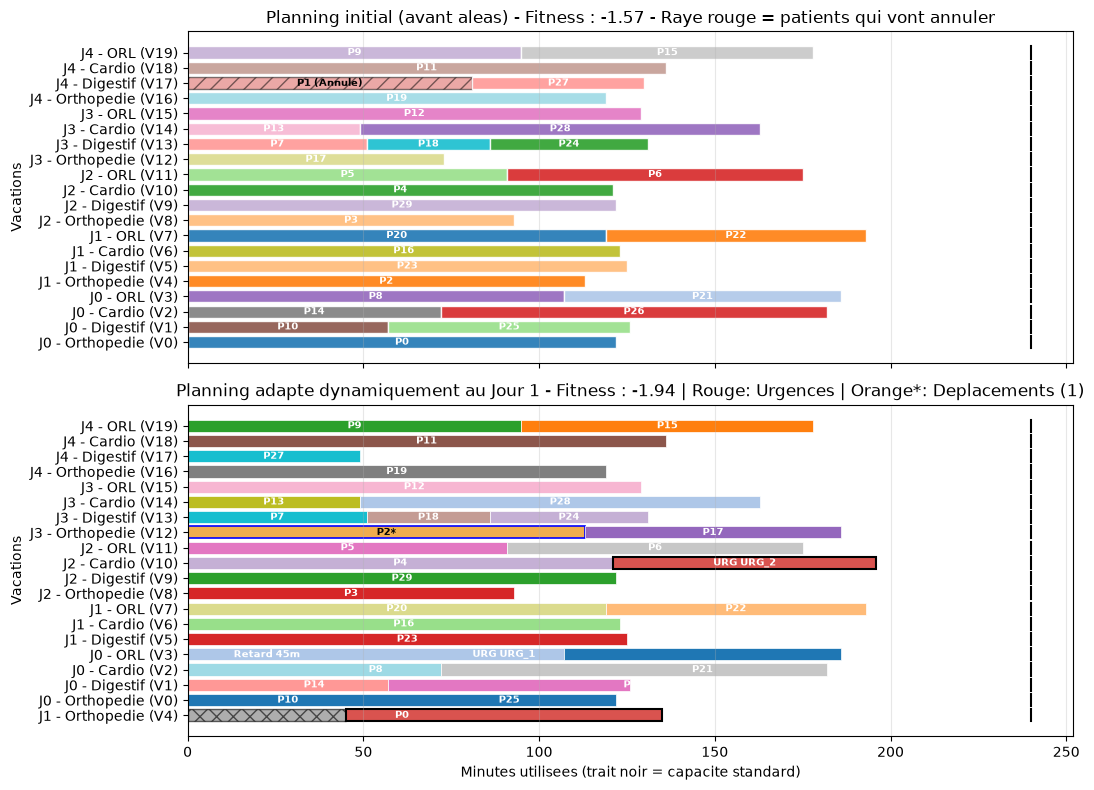

In [10]:
fig_adap = pl.plot_adaptation_dynamique(adaptation_result)
plt.show()

### Impact sur l'hospitalisation et l'occupation des lits

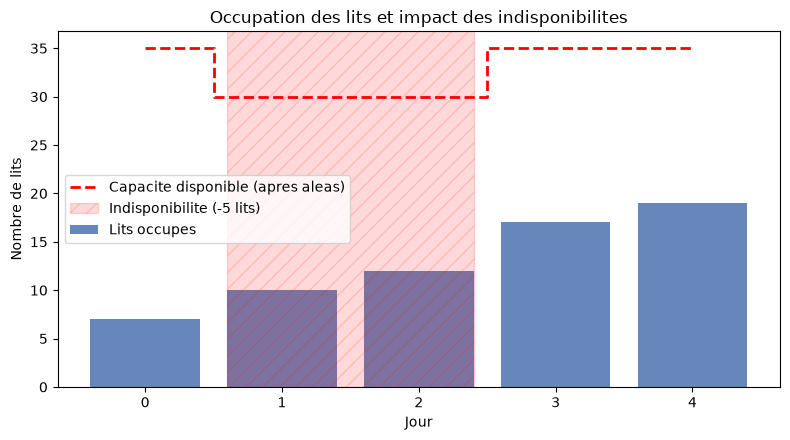

In [11]:
fig_lits_aleas = pl.plot_occupation_lits_aleas(
    adaptation_result.problem_adapte,
    adaptation_result.solution_adaptee,
    indisponibilites=scenario.indisponibilites_lits,
)
plt.show()

## 7. Analyse detaillee des arbitrages d'adaptation

On extrait la liste nominative des patients dont le creneau a du etre adapte pour resorber les tensions creees par les aleas.

In [12]:
if adaptation_result.patients_deplaces:
    lignes_dep = []
    for d in adaptation_result.patients_deplaces:
        lignes_dep.append({
            "Patient": d.patient_id,
            "Avant (Jour, Vac)": f"J{d.jour_avant} - V{d.vacation_avant}",
            "Apres (Jour, Vac)": f"J{d.jour_apres} - V{d.vacation_apres}",
            "Type de changement": "Autre jour" if d.est_changement_jour else "Meme jour (autre salle)",
            "Motif": d.motif,
        })
    df_dep = pd.DataFrame(lignes_dep)
    print("Tableau des deplacements de patients realises :")
    display(df_dep)
else:
    print("Aucun deplacement de patient n'a ete necessaire : les marges du planning ont absorbe l'integralite des aleas !")

Tableau des deplacements de patients realises :


,Patient,"Avant (Jour, Vac)","Apres (Jour, Vac)",Type de changement,Motif
0,2,J1 - V4,J3 - V12,Autre jour,Decalage sur autre jour pour absorber aleas


## 8. Synthese et enseignements operationnels

Ce rapport met en evidence plusieurs resultats essentiels pour l'organisation hospitaliere :

1. **La planification nominale seule est vulnerable** :
   En l'absence de marges de securite, la survenue simultanee d'urgences et de retards entraine des tensions immediates de debordement de vacation et de saturation de lits.

2. **La robustesse proactive reduit les perturbations d'urgence** :
   Le profil **Robuste Bufferise** permet d'absorber une grande partie des retards et des urgences sans devoir reprogrammer de patients electifs.

3. **L'IA offre un arbitrage transparent et mesure** :
   L'adaptation dynamique applique le **principe de moindre perturbation**, preservant les dates deja communiquees aux patients tant que possible, tout en garantissant l'acces aux soins pour les urgences vitales.

4. **Autonomie et decision medicale preservee** :
   Le systeme propose systematiquement des options claires (**Date A / Date B**) et quantifie les impacts, laissant le choix final entre les mains des praticiens et de l'encadrement hospitalier.